# <span style="color:green"> Numerical Simulation Laboratory </span>
## <span style="color:brown"> Python Exercise 11 </span>
## <span style="color:orange"> Keras - Neural Network regression </span>

### Overview 

In this notebook our task will be to perform machine learning regression on noisy data with a Neural Network (NN).

We will explore how the ability to fit depends on the structure of the NN. The goal is also to build intuition about why prediction is difficult.

### The Prediction Problem

Consider a probabilistic process that gives rise to labeled data $(x,y)$. The data is generated by drawing samples from the equation

$$
    y_i= f(x_i) + \eta_i,
$$

where $f(x_i)$ is some fixed, but (possibly unknown) function, and $\eta_i$ is a Gaussian, uncorrelate noise variable such that

$$
\langle \eta_i \rangle=0 \\
\langle \eta_i \eta_j \rangle = \delta_{ij} \sigma
$$

We will refer to the $f(x_i)$ as the **true features** used to generate the data. 

To make predictions, we will consider a NN that depends on its parameters, weights and biases. The functions that the NN can model respresent the **model class** that we are using to try to model the data and make predictions.

To learn the parameters of the NN, we will train our models on a **training data set** and then test the effectiveness of the NN on a *different* dataset, the **validation data set**. The reason we must divide our data into a training and test dataset is that the point of machine learning is to make accurate predictions about new data we have not seen.

To measure our ability to predict, we will learn our parameters by fitting our training dataset and then making predictions on our test data set. One common measure of predictive  performance of our algorithm is to compare the predictions,$\{y_j^\mathrm{pred}\}$, to the true values $\{y_j\}$. A commonly employed measure for this is the sum of the mean square-error (MSE) on the test set:
$$
MSE= \frac{1}{N_\mathrm{test}}\sum_{j=1}^{N_\mathrm{test}} (y_j^\mathrm{pred}-y_j)^2
$$

We will try to get a qualitative picture by examining plots on validation and training data.

### Linear fit

We start by considering the very simple case:
$$
f(x)=2x+1
$$

Let's start defining the parameters of an ideal linear function which we are going to predict through a neural network regression

In [29]:
# target parameters of f(x) = m*x + b
m = 2 # slope
b = 1 # intersect

Now let's generate a set of input data which will slightly deviate from our ideal behaviour using a random noise (that actually is set to zero):

In [30]:
import numpy as np

# --- PARAMETRI DA VARIARE PER L'ESERCIZIO ---
N_train = 500   
sigma = 0.0  
N_epochs = 30   

# generate training inputs
np.random.seed(0)
x_train = np.random.uniform(-1, 1, N_train)
x_valid = np.random.uniform(-1, 1, 50)
x_valid.sort()
y_target = m * x_valid + b # ideal (target) linear function

y_train = np.random.normal(m * x_train + b, sigma) # actual measures from which we want to guess regression parameters
y_valid = np.random.normal(m * x_valid + b, sigma)

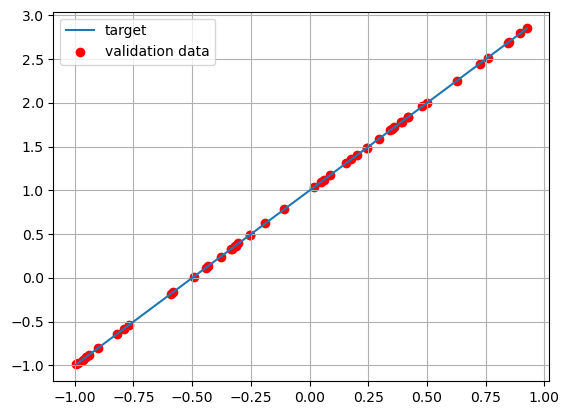

In [31]:
# plot validation and target dataset
import matplotlib.pyplot as plt
plt.plot(x_valid, y_target, label='target')
plt.scatter(x_valid, y_valid, color='r', label='validation data')
plt.legend()
plt.grid(True)
plt.show()

If you remember how a single node of a neural network works, you can easily spot that **just a single neuron can make the job**. So let's start using a simple Sequential model with just one layer on one neuron only!

In [32]:
# compose the NN model
import tensorflow as tf
from tensorflow import keras

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Activation
from tensorflow.keras import backend as K
from tensorflow.keras.utils import get_custom_objects

# Sequential(): Crea un modello in cui i livelli (layers) vengono aggiunti in ordine sequenziale. 
# È il modo standard per definire reti "feed-forward" dove il segnale passa da uno strato all'altro in linea retta.
model = tf.keras.Sequential()
# Dense: Indica uno strato "densamente connesso" (o fully connected), dove ogni neurone riceve in input tutti i valori dallo strato precedente
model.add(Dense(1, input_shape=(1,)))

# La compilazione prepara il modello per l'addestramento, definendo "come" deve imparare
# compile the model choosing optimizer, loss and metrics objects
model.compile(optimizer='sgd', loss='mse', metrics=['mse'])

In [33]:
# get a summary of our composed model
model.summary()

Model: "sequential_12"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_12 (Dense)            (None, 1)                 2         
                                                                 
Total params: 2
Trainable params: 2
Non-trainable params: 0
_________________________________________________________________


We are now going to train our model, that is we feed the neuron with the set of training pair x, y_train from which the optimizer will find the best weights to minimize the Mean Square Error loss function (out linear regression function).

In [34]:
# fit the model using training dataset
# over 10 epochs of 32 batch size each
# report training progress against validation data
history = model.fit(x=x_train, y=y_train, 
          batch_size=32, epochs=N_epochs,
          shuffle=True, # a good idea is to shuffle input before at each epoch
          validation_data=(x_valid, y_valid))

Epoch 1/30
16/16 [==============================] - 1s 18ms/step - loss: 0.9981 - mse: 0.9981 - val_loss: 0.6714 - val_mse: 0.6714
Epoch 2/30
16/16 [==============================] - 0s 4ms/step - loss: 0.5932 - mse: 0.5932 - val_loss: 0.4061 - val_mse: 0.4061
Epoch 3/30
16/16 [==============================] - 0s 4ms/step - loss: 0.3694 - mse: 0.3694 - val_loss: 0.2564 - val_mse: 0.2564
Epoch 4/30
16/16 [==============================] - 0s 6ms/step - loss: 0.2400 - mse: 0.2400 - val_loss: 0.1693 - val_mse: 0.1693
Epoch 5/30
16/16 [==============================] - 0s 5ms/step - loss: 0.1625 - mse: 0.1625 - val_loss: 0.1180 - val_mse: 0.1180
Epoch 6/30
16/16 [==============================] - 0s 5ms/step - loss: 0.1152 - mse: 0.1152 - val_loss: 0.0854 - val_mse: 0.0854
Epoch 7/30
16/16 [==============================] - 0s 5ms/step - loss: 0.0844 - mse: 0.0844 - val_loss: 0.0641 - val_mse: 0.0641
Epoch 8/30
16/16 [==============================] - 0s 5ms/step - loss: 0.0637 - mse: 0.0

By looking at weights and biases we can see if the linear fit was successfull: $w_1$ represents the angular coefficient, $b$ the intercept.

In [35]:
# return weights and biases
model.get_weights()

[array([[1.9654666]], dtype=float32), array([0.9995387], dtype=float32)]

In [36]:
# evaluate model
score = model.evaluate(x_valid, y_valid, batch_size=32, verbose=1)

# print performance
print()
print('Test loss:', score[0])
print('Test accuracy:', score[1])

2/2 [==============================] - 0s 6ms/step - loss: 3.7896e-04 - mse: 3.7896e-04

Test loss: 0.00037896231515333056
Test accuracy: 0.00037896231515333056


In [37]:
# evaluate model with the exact curve
score = model.evaluate(x_valid, y_target, batch_size=32, verbose=1)

# print performance
print()
print('Test loss:', score[0])
print('Test accuracy:', score[1])

2/2 [==============================] - 0s 5ms/step - loss: 3.7896e-04 - mse: 3.7896e-04

Test loss: 0.00037896231515333056
Test accuracy: 0.00037896231515333056


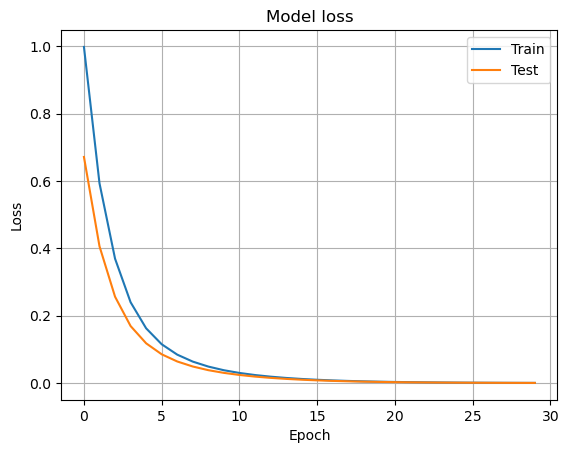

In [38]:
# look into training history
# Plot training & validation loss values
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='best')
plt.grid(True)
plt.show()

4/4 [==============================] - 0s 2ms/step


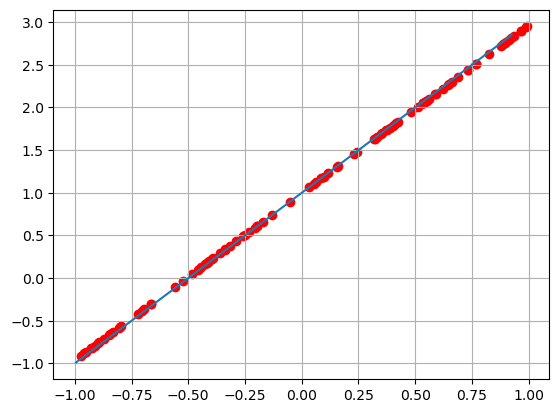

In [39]:
x_predicted = np.random.uniform(-1, 1, 100)
y_predicted = model.predict(x_predicted)
plt.scatter(x_predicted, y_predicted,color='r')
plt.plot(x_valid, y_target)
plt.grid(True)
plt.show()

### Exercise 11.1

In order to make practice with NN, explore how does the previous linear regression depend on the number of epochs, $N_{\mathrm{epochs}}$, the number of data points $N_{\mathrm{train}}$ and on the noise $\sigma$. Try to improve the previous result operating on these parameters.

In [45]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

m_true = 2 
b_true = 1 

lista_N_train = [50, 500, 2000]
lista_sigma   = [0.0, 0.2, 0.5]
lista_epochs  = [10, 50]

risultati = []

print("Esecuzione della griglia di esperimenti in corso...")

tf.get_logger().setLevel('ERROR')

for N_train in lista_N_train:
    for sigma in lista_sigma:
        for N_epochs in lista_epochs:
            
            np.random.seed(0)
            x_train = np.random.uniform(-1, 1, N_train)
            x_valid = np.random.uniform(-1, 1, 50)
            x_valid.sort()
            
            y_target = m_true * x_valid + b_true 
            y_train = np.random.normal(m_true * x_train + b_true, sigma) 
            y_valid = np.random.normal(m_true * x_valid + b_true, sigma)
            
            model = Sequential([Dense(1, input_shape=(1,))])
            model.compile(optimizer='sgd', loss='mse')
            
            model.fit(x=x_train, y=y_train, 
                      batch_size=32, 
                      epochs=N_epochs, 
                      shuffle=True, 
                      validation_data=(x_valid, y_valid), 
                      verbose=0)
            
            weights, bias = model.get_weights()
            m_appreso = weights[0][0]
            b_appreso = bias[0]
            
            err_m = abs(m_true - m_appreso)
            err_b = abs(b_true - b_appreso)
            
            loss_ideale = model.evaluate(x_valid, y_target, batch_size=32, verbose=0)
            
            risultati.append({
                'N_train': N_train,
                'sigma': sigma,
                'epochs': N_epochs,
                'err_m': err_m,
                'err_b': err_b,
                'loss_ideale': loss_ideale
            })


print("\n" + "="*85)
print(f"{'N_train':<10} | {'Sigma':<6} | {'Epochs':<8} || {'Err Peso (m)':<15} | {'Err Bias (b)':<15} | {'Loss Ideale':<15}")
print("="*85)

for r in risultati:
    print(f"{r['N_train']:<10} | {r['sigma']:<6.1f} | {r['epochs']:<8} || {r['err_m']:<15.4f} | {r['err_b']:<15.4f} | {r['loss_ideale']:<15.6f}")

print("="*85)

Esecuzione della griglia di esperimenti in corso...

N_train    | Sigma  | Epochs   || Err Peso (m)    | Err Bias (b)    | Loss Ideale    
50         | 0.0    | 10       || 1.3910          | 0.6277          | 0.784555       
50         | 0.0    | 50       || 0.5040          | 0.0878          | 0.084972       
50         | 0.2    | 10       || 2.4312          | 0.5748          | 1.992654       
50         | 0.2    | 50       || 1.6134          | 0.0771          | 1.011332       
50         | 0.5    | 10       || 0.5837          | 0.5825          | 0.339250       
50         | 0.5    | 50       || 1.7163          | 0.1954          | 1.247926       
500        | 0.0    | 10       || 0.2734          | 0.0429          | 0.024465       
500        | 0.0    | 50       || 0.0072          | 0.0001          | 0.000016       
500        | 0.2    | 10       || 0.7684          | 0.0683          | 0.187503       
500        | 0.2    | 50       || 0.0182          | 0.0217          | 0.000619       
5

### Numero di epoche

Possiamo notare che con pochi dati ($N_{train} = 50$) aumentare il numero di epoche da $10$ a $50$ riduce l'errore se il rumore è nullo. Tuttavia, quando aggiungo il rumore $\sigma = 0.5$ possiamo notare come l'errore sul peso di $m$ peggiori. Questo potrebbe essere un caso di overfitting. La rete dopo $50$ epoche è riuscita a memorizzare l'andamento pochi dati di training e non l'andamento lineare originale.  

Se invece aumento il numero di dati di training ($N_{train} \ge 500$) l'errore diminuisce perchè mediante la discesa stocastica del gradiente, il gradiente viene stimato su molti più punti, risultando in una rete più stabile.

### Numero di dati di training

Facendo aumentare da $N_{train} = 50$ a $N_{train} = 2000$, l'errore sui parametri e il valore della loss function diminuiscono significativamente. In aggiunta quando viene inserito il rumore, avere molti più dati fornisce maggiore statistica nel dataset di training in modo tale che gli errori gaussiani man mano si possano compensare tra di loro, in modo che sia chiaro il trend lineare che deve imparare la rete.

### Valore del rumore

All'aumetare del rumore la loss peggiora. Tuttavia è interessante notare che a parità di rumore $\sigma = 0.5$, con $N_{train} = 2000$ le prestazioni con $10$ epoche sono migliori rispetto alle prestazioni con $50$ epoche. Questo significa che in presenza di rumore la rete non va allenata troppo a lungo, altrimenti va a imparare le caratteristiche stocastiche (data dalla presenza del rumore) del training set.

### Exercise 11.2

Try to extend the model to obtain a reasonable fit of the following polynomial of order 3:

$$
f(x)=4-3x-2x^2+3x^3
$$
for $x \in [-1,1]$.

Find good (& reasonable) choices for:

- the number of layers
- the number of neurons in each layer
- the activation function
- the optimizer
- the loss function
  
Check your NN model by seeing how well your fits predict newly generated test data (including on data outside the range you fit. How well do your NN do on points in the range of $x$ where you trained the model? How about points outside the original training data set? 
Summarize what you have learned about the relationship between model complexity (number of parameters), goodness of fit on training data, and the ability to predict well.

### Architettura della Rete 

- Strato di Input: $1$ nodo.
- Strato Nascosto: $1$ strato denso (Dense) con 100 neuroni.
- Strato di Output: $1$ nodo.

### Funzioni di Attivazione

- ReLU ($f(x) = \max(0, x)$).

### Addestramento e Ottimizzazione

- Ottimizzatore: Adam.
- Loss function: MSE.

### Dati e Configurazione dell'Esperimento

- Training set ($N_{\text{train}}$): 1000 punti campionati uniformemente in $[-1, 1]$.
- Validation set ($N_{\text{valid}}$): 50 punti in $[-1, 1]$.
- Rumore gaussiano ($\sigma$): $0.5$.
- Iperparametri di training: 100 Epoche, Batch size di 32, Shuffle attivo.


 REPORT PERFORMANCE MODELLO POLINOMIALE
Loss (MSE) sui dati di validazione (CON RUMORE): 0.233590
Loss (MSE) rispetto alla curva reale IDEALE:   0.013555



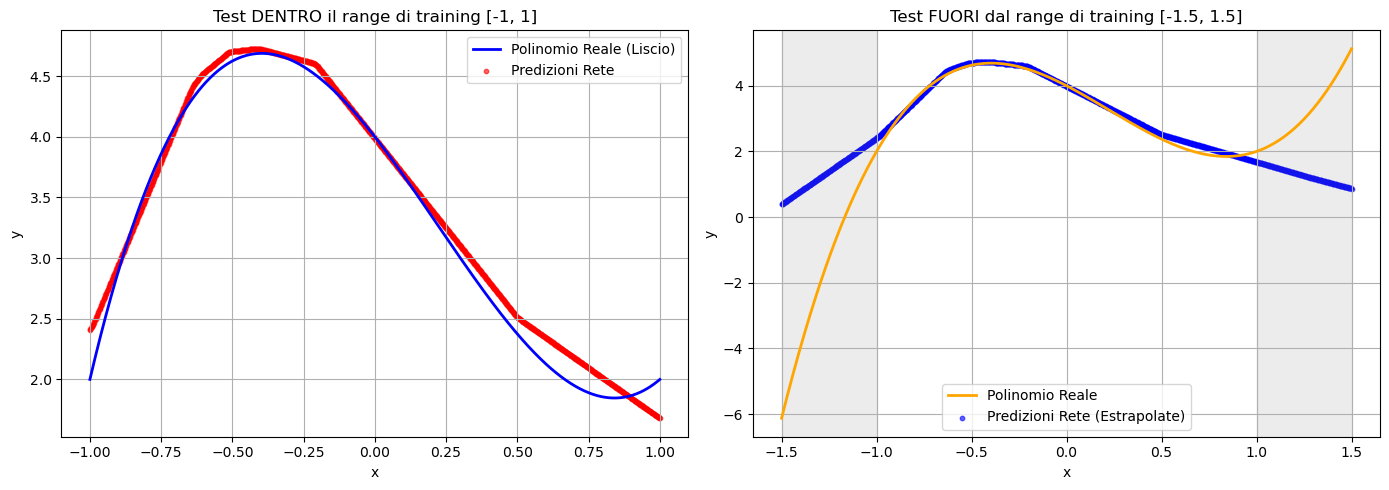

In [10]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# --- FUNZIONE TARGET ---
def f(x, a, b, c, d):
    return a + b*x + c*x**2 + d*x**3

# --- PARAMETRI REALI DEL TARGET (DA INDOVINARE) ---
# f(x) = 4 - 3x - 2x^2 + 3x^3
a_true = 4
b_true = -3 
c_true = -2 
d_true = 3

# --- PARAMETRI RETE E DATASET ---
N_train = 1000 
sigma = 0.5      
N_epochs = 100    

# --- GENERAZIONE DATI DI TRAINING E VALIDAZIONE ---
np.random.seed(0)
x_train = np.random.uniform(-1, 1, N_train)
x_valid = np.random.uniform(-1, 1, 50)
x_valid.sort()

# Target ideale e misure reali corrotte dal rumore (sigma)
y_target_valid = f(x_valid, a_true, b_true, c_true, d_true)
y_train = np.random.normal(f(x_train, a_true, b_true, c_true, d_true), sigma) 
y_valid = np.random.normal(y_target_valid, sigma)

# --- COSTRUZIONE E COMPILAZIONE RETE ---
model = tf.keras.Sequential()
model.add(Dense(100, input_shape=(1,), activation='relu'))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mse', metrics=['mse'])

# --- ADDESTRAMENTO ---
history = model.fit(x=x_train, y=y_train, 
                    batch_size=32, epochs=N_epochs,
                    shuffle=True, 
                    validation_data=(x_valid, y_valid),
                    verbose=0) 

# --- VALUTAZIONE DELLE PERFORMANCE COMPLESSIVE ---
score_noise = model.evaluate(x_valid, y_valid, batch_size=32, verbose=0)
score_exact = model.evaluate(x_valid, y_target_valid, batch_size=32, verbose=0)

print("\n" + "="*60)
print(f" REPORT PERFORMANCE MODELLO POLINOMIALE")
print("="*60)
print(f"Loss (MSE) sui dati di validazione (CON RUMORE): {score_noise[0]:.6f}")
print(f"Loss (MSE) rispetto alla curva reale IDEALE:   {score_exact[0]:.6f}")
print("="*60 + "\n")


plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)

x_pred_inside = np.linspace(-1, 1, 1000) 
y_pred_inside = model.predict(x_pred_inside, verbose=0)
y_target_inside_smooth = f(x_pred_inside, a_true, b_true, c_true, d_true)

plt.plot(x_pred_inside, y_target_inside_smooth, color='blue', linewidth=2, label='Polinomio Reale (Liscio)')
plt.scatter(x_pred_inside, y_pred_inside, color='red', s=10, alpha=0.6, label='Predizioni Rete')
plt.title('Test DENTRO il range di training [-1, 1]')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
x_extended = np.linspace(-1.5, 1.5, 1000) 
y_target_extended = f(x_extended, a_true, b_true, c_true, d_true)
y_pred_outside = model.predict(x_extended, verbose=0)

plt.plot(x_extended, y_target_extended, color='orange', linewidth=2, label='Polinomio Reale')
plt.scatter(x_extended, y_pred_outside, color='blue', s=10, alpha=0.6, label='Predizioni Rete (Estrapolate)')
plt.axvspan(-1.5, -1, color='gray', alpha=0.15)
plt.axvspan(1, 1.5, color='gray', alpha=0.15)
plt.title('Test FUORI dal range di training [-1.5, 1.5]')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

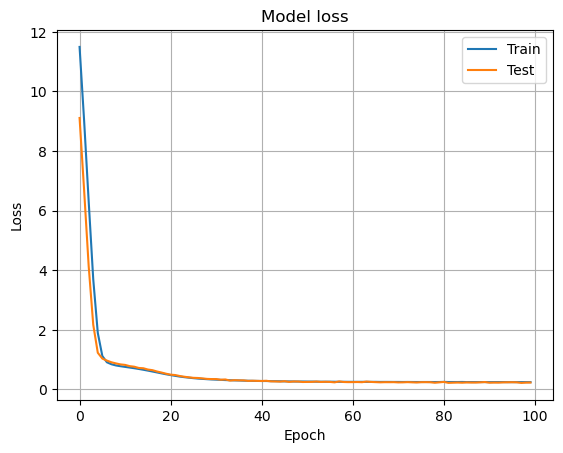

In [11]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='best')
plt.grid(True)
plt.show()

La rete ha appreso abbastanza bene all'interno dell'intervallo di training. Essendo la funzione di attivazione la ReLu, la curva appresa risulta un po' spigolosa. Al di fuori dell'intervallo di training la rete fallisce completamente dell'operazione di estrapolazione del polinomio.

### Architettura della Rete 

- Strato di Input: $1$ nodo.
- Strati Nascosti: $2$ strati densi (Dense) con 20 neuroni.
- Strato di Output: $1$ nodo.

### Funzioni di Attivazione

- tanh.

### Addestramento e Ottimizzazione

- Ottimizzatore: Adam.
- Loss function: MSE.

### Dati e Configurazione dell'Esperimento

- Training set ($N_{\text{train}}$): 1000 punti campionati uniformemente in $[-1, 1]$.
- Validation set ($N_{\text{valid}}$): 50 punti in $[-1, 1]$.
- Rumore gaussiano ($\sigma$): $0.5$.
- Iperparametri di training: 100 Epoche, Batch size di 32, Shuffle attivo.


 PERFORMANCE MODELLO POLINOMIALE (1 layer, 20 neuroni)
Loss (MSE) sui dati di validazione (CON RUMORE): 0.237314
Loss (MSE) rispetto alla curva reale IDEALE:   0.026440



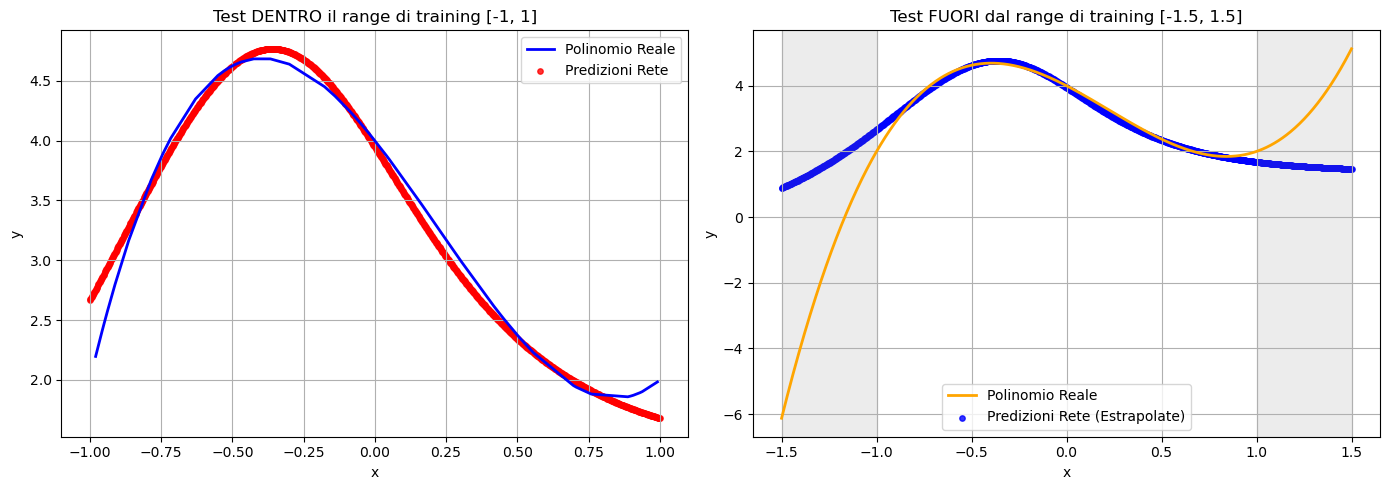

In [3]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

def f(x, a, b, c, d):
    return a + b*x + c*x**2 + d*x**3

# --- PARAMETRI REALI DEL TARGET (DA INDOVINARE) ---
a_true = 4
b_true = -3 
c_true = -2 
d_true = 3

# --- PARAMETRI RETE ---
N_train = 1000 
sigma = 0.5 
N_epochs = 100    

np.random.seed(0)
x_train = np.random.uniform(-1, 1, N_train)
x_valid = np.random.uniform(-1, 1, 50)
x_valid.sort()

y_target = f(x_valid, a_true, b_true, c_true, d_true)

y_train = np.random.normal(f(x_train, a_true, b_true, c_true, d_true), sigma) 
y_valid = np.random.normal(f(x_valid, a_true, b_true, c_true, d_true), sigma)

# COSTRUZIONE E COMPILAZIONE RETE
model = tf.keras.Sequential()
model.add(Dense(20, input_shape=(1,), activation='tanh'))
model.add(Dense(20, activation='tanh'))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mse', metrics=['mse'])

# ADDESTRAMENTO
history = model.fit(x=x_train, y=y_train, 
                    batch_size=32, epochs=N_epochs,
                    shuffle=True, 
                    validation_data=(x_valid, y_valid),
                    verbose=0)

# VALUTAZIONE DELLE PERFORMANCE COMPLESSIVE
score_noise = model.evaluate(x_valid, y_valid, batch_size=32, verbose=0)
score_exact = model.evaluate(x_valid, y_target, batch_size=32, verbose=0)

print("\n" + "="*50)
print(f" PERFORMANCE MODELLO POLINOMIALE (1 layer, 20 neuroni)")
print("="*50)
print(f"Loss (MSE) sui dati di validazione (CON RUMORE): {score_noise[0]:.6f}")
print(f"Loss (MSE) rispetto alla curva reale IDEALE:   {score_exact[0]:.6f}")
print("="*50 + "\n")


plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
x_pred_inside = np.linspace(-1, 1, 1000)
y_pred_inside = model.predict(x_pred_inside, verbose=0)

plt.plot(x_valid, y_target, color='blue', linewidth=2, label='Polinomio Reale')
plt.scatter(x_pred_inside, y_pred_inside, color='red', s=15, alpha=0.8, label='Predizioni Rete')
plt.title('Test DENTRO il range di training [-1, 1]')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)

x_extended = np.linspace(-1.5, 1.5, 1000)
y_target_extended = f(x_extended, a_true, b_true, c_true, d_true)
y_pred_outside = model.predict(x_extended, verbose=0)

plt.plot(x_extended, y_target_extended, color='orange', linewidth=2, label='Polinomio Reale')
plt.scatter(x_extended, y_pred_outside, color='blue', s=15, alpha=0.8, label='Predizioni Rete (Estrapolate)')
plt.axvspan(-1.5, -1, color='gray', alpha=0.15) # Evidenzia la zona sconosciuta a sinistra
plt.axvspan(1, 1.5, color='gray', alpha=0.15)  # Evidenzia la zona sconosciuta a destra
plt.title('Test FUORI dal range di training [-1.5, 1.5]')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

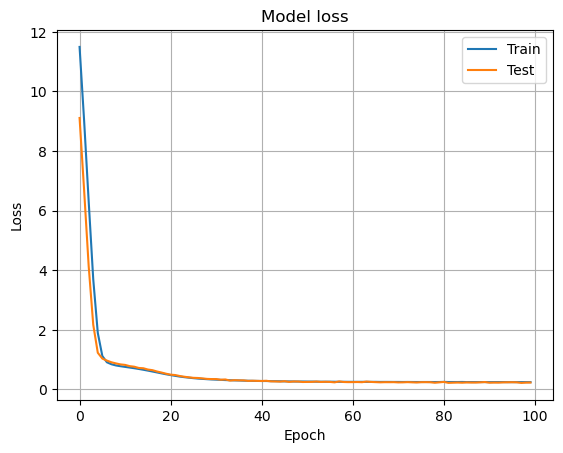

In [12]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='best')
plt.grid(True)
plt.show()

All'interno dell'intervallo di training la rete possiede buone capacità di interpolazione. La curva interpolata in questo caso risulta più morbida a causa della scelta della funzione di attivazione tanh che risulta derivabile. Tuttavia, anche in questo caso la curva non riesce a generalizzare al di fuori dell'intervallo di training

### Architettura della Rete 

- Strato di Input: $1$ nodo.
- Strato Nascosto: $5$ strati densi (Dense) con $20 \rightarrow 50 \rightarrow 500 \rightarrow 50 \rightarrow 20$ neuroni.
- Strato di Output: $1$ nodo.

### Funzioni di Attivazione

- tanh.

### Addestramento e Ottimizzazione

- Ottimizzatore: Adam.
- Loss function: MSE.

### Dati e Configurazione dell'Esperimento

- Training set ($N_{\text{train}}$): 1000 punti campionati uniformemente in $[-1, 1]$.
- Validation set ($N_{\text{valid}}$): 50 punti in $[-1, 1]$.
- Rumore gaussiano ($\sigma$): $0.5$.
- Iperparametri di training: 100 Epoche, Batch size di 32, Shuffle attivo.


 PERFORMANCE MODELLO POLINOMIALE (1 layer, 20 neuroni)
Loss (MSE) sui dati di validazione (CON RUMORE): 0.235573
Loss (MSE) rispetto alla curva reale IDEALE:   0.024696



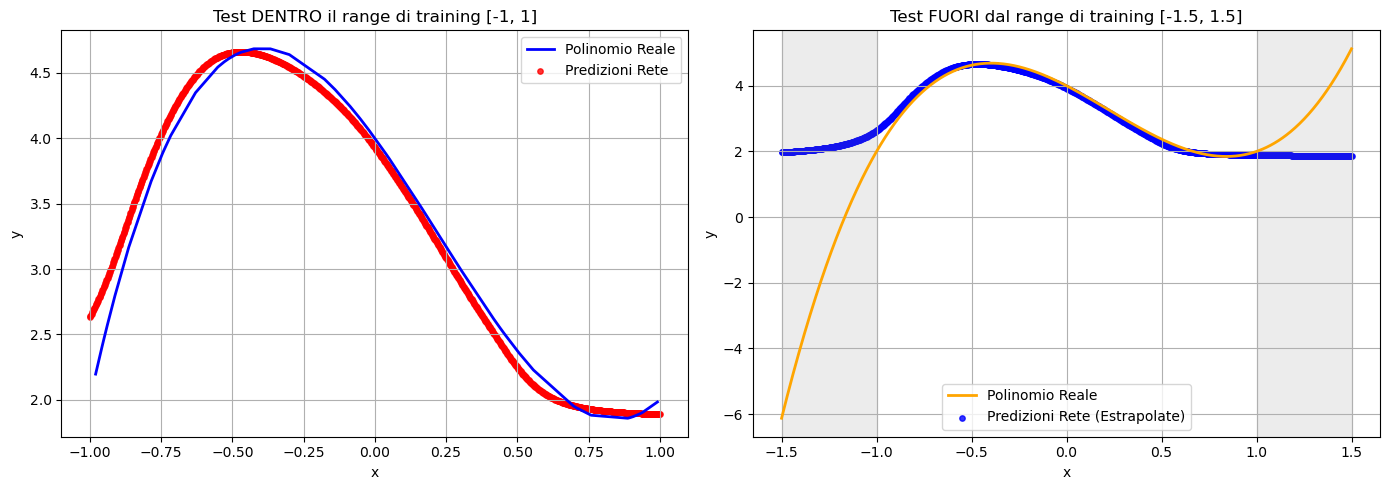

In [16]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

def f(x, a, b, c, d):
    return a + b*x + c*x**2 + d*x**3

# --- PARAMETRI REALI DEL TARGET (DA INDOVINARE) ---
a_true = 4
b_true = -3 
c_true = -2 
d_true = 3

# --- PARAMETRI RETE ---
N_train = 1000
sigma = 0.5 
N_epochs = 100    

np.random.seed(0)
x_train = np.random.uniform(-1, 1, N_train)
x_valid = np.random.uniform(-1, 1, 50)
x_valid.sort()

y_target = f(x_valid, a_true, b_true, c_true, d_true)

y_train = np.random.normal(f(x_train, a_true, b_true, c_true, d_true), sigma) 
y_valid = np.random.normal(f(x_valid, a_true, b_true, c_true, d_true), sigma)

# COSTRUZIONE E COMPILAZIONE RETE
model = tf.keras.Sequential()
model.add(Dense(20, input_shape=(1,), activation='tanh'))
model.add(Dense(50, activation='tanh'))
model.add(Dense(500, activation='tanh'))
model.add(Dense(50, activation='tanh'))
model.add(Dense(20, activation='tanh'))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mse', metrics=['mse'])

# ADDESTRAMENTO
history = model.fit(x=x_train, y=y_train, 
                    batch_size=32, epochs=N_epochs,
                    shuffle=True, 
                    validation_data=(x_valid, y_valid),
                    verbose=0)

# VALUTAZIONE DELLE PERFORMANCE COMPLESSIVE
score_noise = model.evaluate(x_valid, y_valid, batch_size=32, verbose=0)
score_exact = model.evaluate(x_valid, y_target, batch_size=32, verbose=0)

print("\n" + "="*50)
print(f" PERFORMANCE MODELLO POLINOMIALE (1 layer, 20 neuroni)")
print("="*50)
print(f"Loss (MSE) sui dati di validazione (CON RUMORE): {score_noise[0]:.6f}")
print(f"Loss (MSE) rispetto alla curva reale IDEALE:   {score_exact[0]:.6f}")
print("="*50 + "\n")


plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
x_pred_inside = np.linspace(-1, 1, 1000)
y_pred_inside = model.predict(x_pred_inside, verbose=0)

plt.plot(x_valid, y_target, color='blue', linewidth=2, label='Polinomio Reale')
plt.scatter(x_pred_inside, y_pred_inside, color='red', s=15, alpha=0.8, label='Predizioni Rete')
plt.title('Test DENTRO il range di training [-1, 1]')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
x_extended = np.linspace(-1.5, 1.5, 1000)
y_target_extended = f(x_extended, a_true, b_true, c_true, d_true)
y_pred_outside = model.predict(x_extended, verbose=0)

plt.plot(x_extended, y_target_extended, color='orange', linewidth=2, label='Polinomio Reale')
plt.scatter(x_extended, y_pred_outside, color='blue', s=15, alpha=0.8, label='Predizioni Rete (Estrapolate)')
plt.axvspan(-1.5, -1, color='gray', alpha=0.15) # Evidenzia la zona sconosciuta a sinistra
plt.axvspan(1, 1.5, color='gray', alpha=0.15)  # Evidenzia la zona sconosciuta a destra
plt.title('Test FUORI dal range di training [-1.5, 1.5]')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

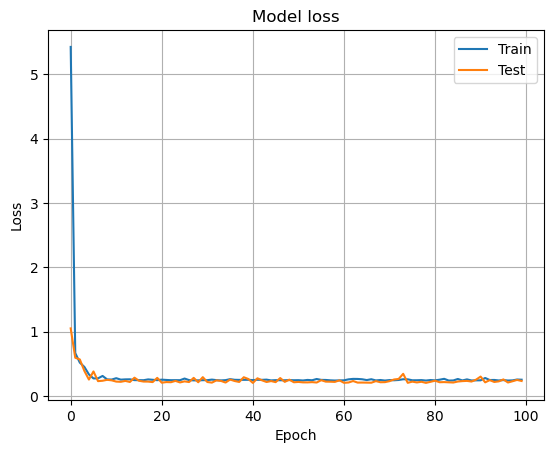

In [18]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='best')
plt.grid(True)
plt.show()

Questa rete risulta la perggiore sia dal punto di vista dell'interpolazione sia dell'estrapolazione. La struttura neurale "complessa" che possiede non le ha conferito alcun vantaggio rispetto alle reti neurali analizzate precedentemente.

### Exercise 11.3
  
Try to extend the model to fit a simple trigonometric 2D function such as $f(x,y) = \sin(x^2+y^2)$ in the range $x \in [-3/2,3/2]$ and $y \in [-3/2,3/2]$.

Ideas to meditate on these exercises and judge your results can be found <a href=https://xkcd.com/2048/>here</a>

### Architettura della Rete 

- Strato di Input: $2$ nodi.
- Strati Nascosti: $3$ strati densi (Dense) con $64 \rightarrow 32 \rightarrow 16$ neuroni.
- Strato di Output: $1$ nodo.

### Funzioni di Attivazione

- tanh.

### Addestramento e Ottimizzazione

- Ottimizzatore: Adam.
- Loss function: MSE.

### Dati e Configurazione dell'Esperimento

- Training set ($N_{\text{train}}$): 1000 coppie di punti campionati uniformemente nel piano $[-1.5, 1.5] \times [-1.5, 1.5]$.
- Validation set ($N_{\text{valid}}$): 50 coppie di punti nel piano $[-1.5, 1.5] \times [-1.5, 1.5]$.
- Rumore gaussiano ($\sigma$): $0.5$.
- Iperparametri di training: 100 Epoche, Batch size di 32, Shuffle attivo.

In [21]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

def f(x, y):
    return np.sin(x**2 + y**2)

# --- PARAMETRI RETE ---
N_train = 1000
sigma = 0.5 
N_epochs = 200    

np.random.seed(0)

x_train = np.random.uniform(-1.5, 1.5, N_train)
x_valid = np.random.uniform(-1.5, 1.5, 50)

y_train = np.random.uniform(-1.5, 1.5, N_train)
y_valid = np.random.uniform(-1.5, 1.5, 50)

z_target = f(x_valid, y_valid)

z_train = np.random.normal(f(x_train, y_train), sigma) 
z_valid = np.random.normal(f(x_valid, y_valid), sigma)

xy_train = np.column_stack((x_train, y_train))
xy_valid = np.column_stack((x_valid, y_valid))

# COSTRUZIONE E COMPILAZIONE RETE
model = tf.keras.Sequential()
model.add(Dense(64, input_shape=(2,), activation='tanh'))  
model.add(Dense(32, activation='tanh'))                  
model.add(Dense(16, activation='tanh'))    
model.add(Dense(1))

model.compile(optimizer='adam', loss='mse', metrics=['mse'])

# --- ADDESTRAMENTO CORRETTO ---
history = model.fit(
    x=xy_train,          
    y=z_train,          
    batch_size=32, 
    epochs=N_epochs,
    shuffle=True, 
    validation_data=(xy_valid, z_valid), 
    verbose=0
)

# --- VALUTAZIONE PERFORMANCE ---
score_noise = model.evaluate(xy_valid, z_valid, verbose=0)
score_exact = model.evaluate(xy_valid, z_target, verbose=0)

print("\n" + "="*50)
print(f" PERFORMANCE MODELLO 2D : sin(x^2 + y^2)")
print("="*50)
print(f"Loss (MSE) di validazione (CON RUMORE): {score_noise[0]:.6f}")
print(f"Loss (MSE) rispetto al target IDEALE:   {score_exact[0]:.6f}")
print("="*50 + "\n")


 PERFORMANCE MODELLO 2D : sin(x^2 + y^2)
Loss (MSE) di validazione (CON RUMORE): 0.250567
Loss (MSE) rispetto al target IDEALE:   0.019819



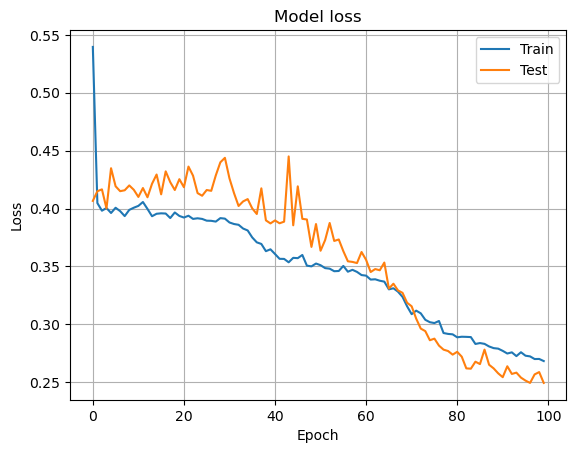

In [20]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='best')
plt.grid(True)
plt.show()

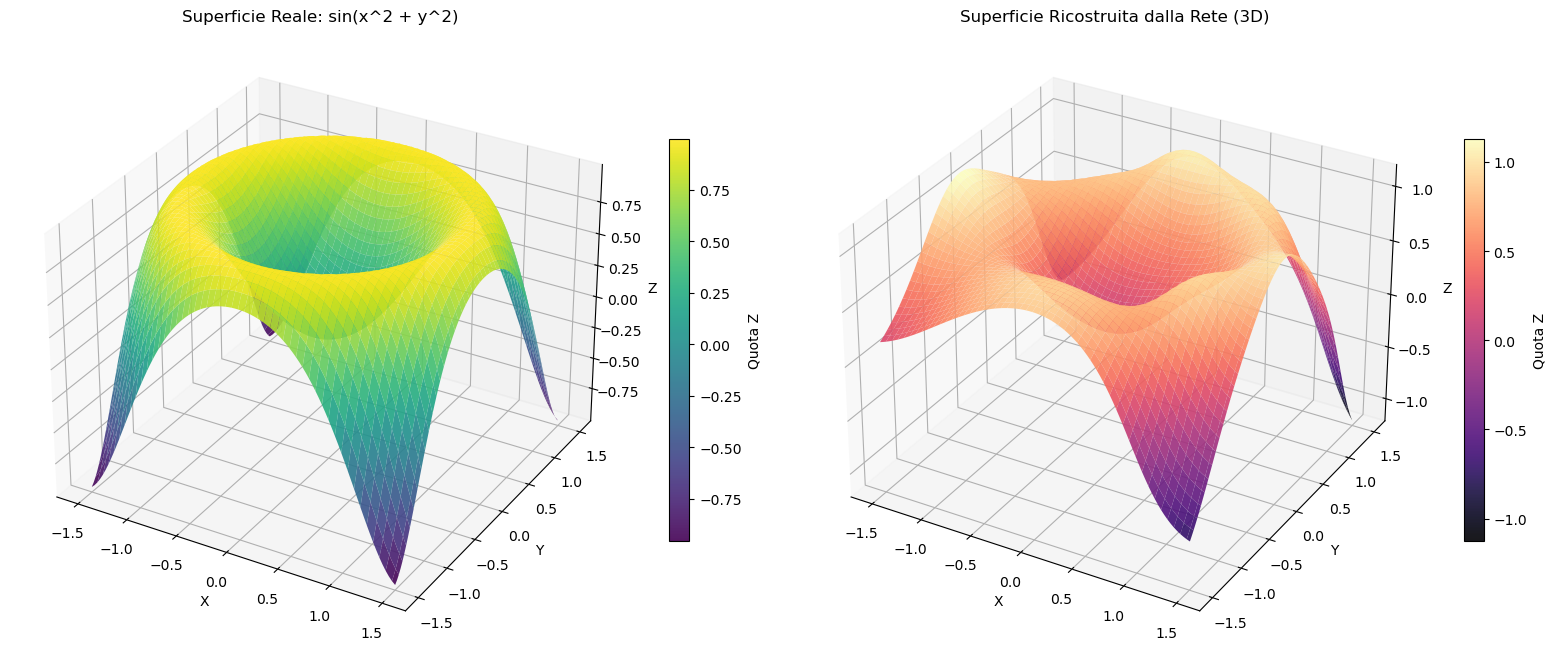

In [87]:
from mpl_toolkits.mplot3d import Axes3D  # Importo esplicitamente per le proiezioni 3D

# =====================================================================
# GRAFICHI DI CONFRONTO IN 3D (SUPERFICI)
# =====================================================================

# 1. Creiamo una griglia fitta sul piano [-1.5, 1.5]
x_plot = np.linspace(-1.5, 1.5, 100) # 100 punti sono sufficienti per una buona superficie
y_plot = np.linspace(-1.5, 1.5, 100)
X_grid, Y_grid = np.meshgrid(x_plot, y_plot)

# Calcoliamo il target reale sulla griglia
Z_target_grid = f(X_grid, Y_grid)

# Prepariamo i punti per darli in pasto a model.predict
# Ravel appiattisce le griglie 2D in array 1D
xy_pred_grid = np.column_stack((X_grid.ravel(), Y_grid.ravel()))
Z_pred_flat = model.predict(xy_pred_grid, verbose=0)
# Ricreiamo la forma della griglia 2D per il plot
Z_pred_grid = Z_pred_flat.reshape(X_grid.shape)

# 2. Creazione del plot
fig = plt.figure(figsize=(16, 7))

# --- GRAFICO 1: Superficie Reale (3D) ---
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
# plot_surface crea la superficie 3D. cmap='viridis' è la mappa colori reale
surf1 = ax1.plot_surface(X_grid, Y_grid, Z_target_grid, cmap='viridis', edgecolor='none', alpha=0.9)
fig.colorbar(surf1, ax=ax1, label='Quota Z', shrink=0.6) # Colora bar shrunk per allinearsi
ax1.set_title('Superficie Reale: sin(x^2 + y^2)')
ax1.set_xlabel('X')
ax1.set_ylabel('Y')
ax1.set_zlabel('Z')

# --- GRAFICO 2: Superficie Predetta dalla Rete (3D) ---
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
# Usiamo cmap='magma' per la rete per distinguere visivamente i due grafici
surf2 = ax2.plot_surface(X_grid, Y_grid, Z_pred_grid, cmap='magma', edgecolor='none', alpha=0.9)
fig.colorbar(surf2, ax=ax2, label='Quota Z', shrink=0.6)
ax2.set_title('Superficie Ricostruita dalla Rete (3D)')
ax2.set_xlabel('X')
ax2.set_ylabel('Y')
ax2.set_zlabel('Z')

plt.tight_layout()
plt.show()

La rete è riuscita a imparare la funzione target abbastanza fedelmente, senza memorizzare gli errori gaussiani a cui era sottoposta.

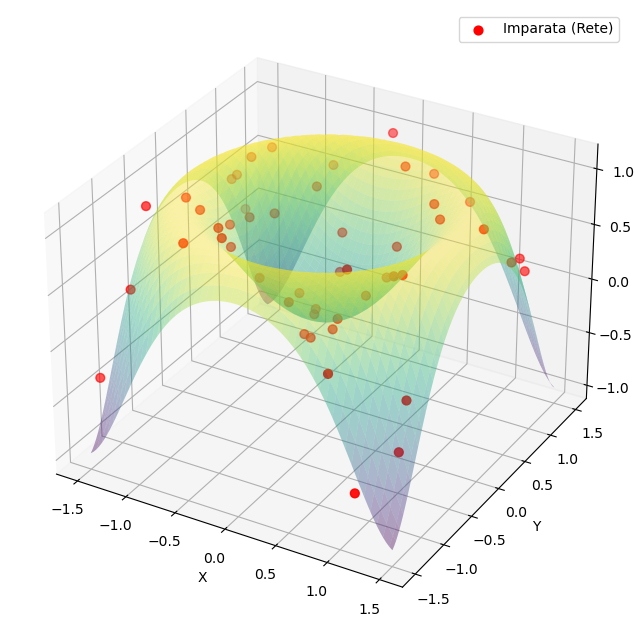

In [24]:
z_pred = model.predict(xy_valid, verbose=0).flatten()

x_g, y_g = np.meshgrid(np.linspace(-1.5, 1.5, 100), np.linspace(-1.5, 1.5, 100))
z_g = f(x_g, y_g)

# 3. Grafico 3D
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(projection='3d')
ax.plot_surface(x_g, y_g, z_g, cmap='viridis', alpha=0.4)
ax.scatter(x_valid, y_valid, z_pred, color='red', s=40, label='Imparata (Rete)')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.legend()
plt.show()